In [1]:
import numpy as np
import matplotlib.pyplot as plt

ppm = np.array([
    [0.10576923, 0.77884615, 0.10576923, 0.00961538, 0.00961538, 0.20192308, 0.68269231, 0.20192308, 0.10576923],
    [0.58653846, 0.20192308, 0.10576923, 0.00961538, 0.00961538, 0.58653846, 0.00961538, 0.00961538, 0.77884615],
    [0.10576923, 0.00961538, 0.77884615, 0.97115385, 0.00961538, 0.00961538, 0.29807692, 0.77884615, 0.00961538],
    [0.20192308, 0.00961538, 0.00961538, 0.00961538, 0.97115385, 0.20192308, 0.00961538, 0.00961538, 0.10576923]
])  # 4 bases x 9 positions, rows = A, C, G, T

def shannon_entropy(col):
    return -np.sum([p * np.log2(p) if p > 0 else 0 for p in col])

H = np.array([shannon_entropy(ppm[:, i]) for i in range(9)])
IC = 2 - H

print("H(i): ", np.round(H, 4))
print("IC(i):", np.round(IC, 4))

H(i):  [1.6031 0.8758 1.0309 0.2343 0.2343 1.448  1.0253 0.8758 1.0309]
IC(i): [0.3969 1.1242 0.9691 1.7657 1.7657 0.552  0.9747 1.1242 0.9691]


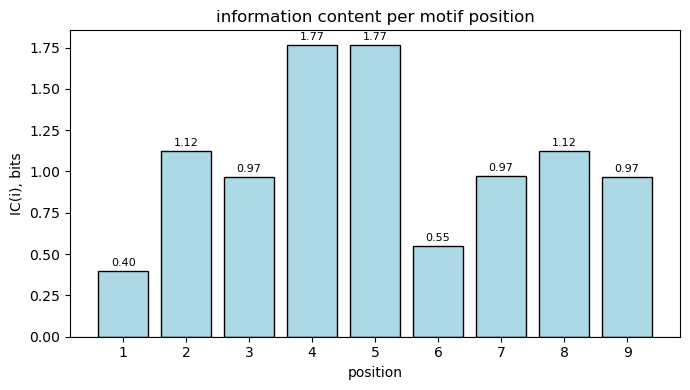

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
positions = np.arange(1, 10)
bars = ax.bar(positions, IC, color='lightblue', edgecolor='black')
ax.set_xlabel('position')
ax.set_ylabel('IC(i), bits')
ax.set_title('information content per motif position')
ax.set_xticks(positions)
ax.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, IC):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, f'{val:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('ic_barplot.png', dpi=150)
plt.show()

In [4]:
threshold = 1.0
core = [i+1 for i, v in enumerate(IC) if v >= threshold]
variable = [i+1 for i, v in enumerate(IC) if v < threshold]

print(f'core positions (IC >= {threshold}): {core}')
print(f'variable positions (IC < {threshold}): {variable}')
print()

core positions (IC >= 1.0): [2, 4, 5, 8]
variable positions (IC < 1.0): [1, 3, 6, 7, 9]



Позиции 4 и 5: IC ~2 (консервативны: G и T)
Позиции 2,7,8: высокий IC — часть основного мотива
Позиции 1,3,6,9: вариабельны (IC < 1)
Согласуется с визуально: колонки 4–5 почти мономорфны